In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
incident_angles = np.array([0, 10, 20, 30, 40])
refracted_angles = np.array([26, 34, 47, 60, 83])

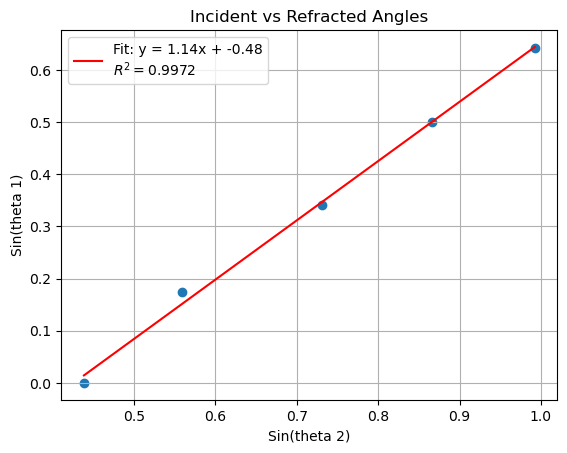

In [5]:
y = np.sin(np.radians(incident_angles))
x = np.sin(np.radians(refracted_angles))

stdx = np.std(x, ddof=1)
stdy = np.std(y, ddof=1)

m, c = np.polyfit(x, y, 1)
line = m * x + c
correlation_matrix = np.corrcoef(x, y)
r_squared = correlation_matrix[0, 1]**2

plt.scatter(x, y)
plt.plot(x, line, color="red", label=f'Fit: y = {m:.2f}x + {c:.2f}\n$R^2 = {r_squared:.4f}$')
plt.xlabel('Sin(theta 2)')
plt.ylabel('Sin(theta 1)')
plt.title('Incident vs Refracted Angles')
plt.legend()
plt.grid()

In [6]:
n1 = m

criticalAngle = np.arcsin(1/n1)
criticalAngle = np.degrees(criticalAngle)

print(criticalAngle)

61.6225395850367


Preliminary Setup

In [7]:
# Measurement uncertainty in degrees and radians
s_theta_deg = 1.0
s_theta_rad = np.radians(s_theta_deg)

Method I - Propogation using Derivatives

- This method uses the derivative of the sine function multiplied by the angular uncertainty in radians.

In [8]:
# Calculate uncertainty using Method I
unc_sin_inc_m1 = np.abs(np.cos(np.radians(incident_angles))) * s_theta_rad
unc_sin_ref_m1 = np.abs(np.cos(np.radians(refracted_angles))) * s_theta_rad

print(f"Method 1 - Incident Uncertainties: {unc_sin_inc_m1}")
print(f"Method 1 - Refracted Uncertainties: {unc_sin_ref_m1}")

Method 1 - Incident Uncertainties: [0.01745329 0.01718814 0.01640073 0.01511499 0.01337   ]
Method 1 - Refracted Uncertainties: [0.01568692 0.01446944 0.01190312 0.00872665 0.00212702]


Method II - Half Difference Method

- This method calculated half the absolute difference between the function evaluated at the upper and lower bounds of the uncertainty

In [9]:
# Calculate uncertainty using Method II
unc_sin_inc_m2 = 0.5 * np.abs(np.sin(np.radians(incident_angles + s_theta_deg)) - 
                              np.sin(np.radians(incident_angles - s_theta_deg)))

unc_sin_ref_m2 = 0.5 * np.abs(np.sin(np.radians(refracted_angles + s_theta_deg)) - 
                              np.sin(np.radians(refracted_angles - s_theta_deg)))

print(f"Method 2 - Incident Uncertainties: {unc_sin_inc_m2}")
print(f"Method 2 - Refracted Uncertainties: {unc_sin_ref_m2}")

Method 2 - Incident Uncertainties: [0.01745241 0.01718727 0.0163999  0.01511423 0.01336932]
Method 2 - Refracted Uncertainties: [0.01568612 0.0144687  0.01190251 0.0087262  0.00212691]


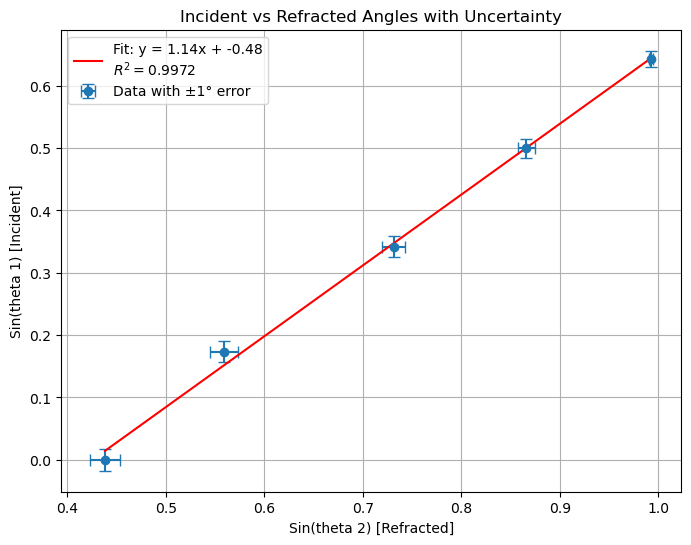

In [10]:
y = np.sin(np.radians(incident_angles))
x = np.sin(np.radians(refracted_angles))

m, c = np.polyfit(x, y, 1)
line = m * x + c
correlation_matrix = np.corrcoef(x, y)
r_squared = correlation_matrix[0, 1]**2

plt.figure(figsize=(8, 6))

# Replacing plt.scatter with plt.errorbar to show the uncertainties calculated in Method 2
plt.errorbar(x, y, xerr=unc_sin_ref_m2, yerr=unc_sin_inc_m2, fmt='o', capsize=4, label='Data with ±1° error')
plt.plot(x, line, color="red", label=f'Fit: y = {m:.2f}x + {c:.2f}\n$R^2 = {r_squared:.4f}$')

plt.xlabel('Sin(theta 2) [Refracted]')
plt.ylabel('Sin(theta 1) [Incident]')
plt.title('Incident vs Refracted Angles with Uncertainty')
plt.legend()
plt.grid()
plt.savefig("updated_plot.png")

Lack of Data near the Critical Angle

- We only have 5 points, and they stop at 40°,

- Without data points between 40° and the actual critical angle (where the light hits 90°), the linear fit is guessing the slope based on the flatter part of the curve.

Uncertainties

- Uncertainty in the measurement was $\pm\,1 \degree$